In [1]:
import os
os.chdir('/mnt/d/KU_year3/Statistics/stat_csv')
os.getcwd()

'/mnt/d/KU_year3/Statistics/stat_csv'

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## Load dataset

In [4]:
orig_df = pd.read_csv("bike_day.csv")
orig_df.head(10)

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600
5,6,2011-01-06,1,0,1,0,4,1,1,0.204348,0.233209,0.518261,0.089565,88,1518,1606
6,7,2011-01-07,1,0,1,0,5,1,2,0.196522,0.208839,0.498696,0.168726,148,1362,1510
7,8,2011-01-08,1,0,1,0,6,0,2,0.165000,0.162254,0.535833,0.266804,68,891,959
8,9,2011-01-09,1,0,1,0,0,0,1,0.138333,0.116175,0.434167,0.361950,54,768,822
9,10,2011-01-10,1,0,1,0,1,1,1,0.150833,0.150888,0.482917,0.223267,41,1280,1321


In [5]:
orig_df.shape

(731, 16)

In [6]:
df = orig_df.drop(["instant", "dteday"], axis=1)
df = df.copy()
orig_X = df.drop("cnt", axis=1)
X = orig_X.copy()

## Handling Missing Values

<Axes: >

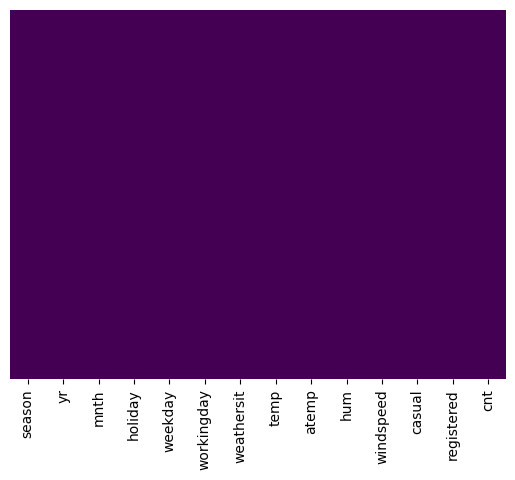

In [7]:
# Plot heatmap to visualize locations of missing values
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')

In [8]:
# find missing value percent for each variable
null_percent = df.isnull().sum()/len(df)*100
null_percent

season        0.0
yr            0.0
mnth          0.0
holiday       0.0
weekday       0.0
workingday    0.0
weathersit    0.0
temp          0.0
atemp         0.0
hum           0.0
windspeed     0.0
casual        0.0
registered    0.0
cnt           0.0
dtype: float64

## Handling Outliers

In [9]:
def remove_outliers_iqr(df, outlier_vars):
    temp_df = df.copy()
    for _var in outlier_vars:
        q1 = temp_df[_var].quantile(0.25)
        q3 = temp_df[_var].quantile(0.75)
        iqr = q3-q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        mask = (temp_df[_var] < lower_bound) | (temp_df[_var] > upper_bound)
        temp_df = temp_df[~mask]
        print(temp_df.shape)
    return temp_df

## Handling Skewness

array([[<Axes: title={'center': 'season'}>,
        <Axes: title={'center': 'yr'}>, <Axes: title={'center': 'mnth'}>,
        <Axes: title={'center': 'holiday'}>],
       [<Axes: title={'center': 'weekday'}>,
        <Axes: title={'center': 'workingday'}>,
        <Axes: title={'center': 'weathersit'}>,
        <Axes: title={'center': 'temp'}>],
       [<Axes: title={'center': 'atemp'}>,
        <Axes: title={'center': 'hum'}>,
        <Axes: title={'center': 'windspeed'}>,
        <Axes: title={'center': 'casual'}>],
       [<Axes: title={'center': 'registered'}>, <Axes: >, <Axes: >,
        <Axes: >]], dtype=object)

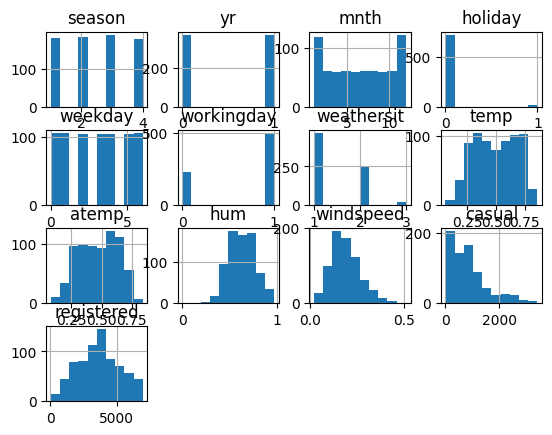

In [10]:
X.hist()

In [11]:
def transform_log(X, skew_var):
    temp_X = X.copy()
    temp_X[skew_var] = np.log1p(temp_X[skew_var])   # log1p = log(1 + y)
    return temp_X
    
def transform_boxcox(X, skew_var):
    temp_X = X.copy()
    from scipy.stats import boxcox
    temp_bc, lambda_bc = boxcox(temp_X[skew_var])
    temp_X[skew_var] = temp_bc
    return temp_X

def transform_yeojohnson(X, skew_var):
    temp_X = X.copy()
    from sklearn.preprocessing import PowerTransformer
    pt = PowerTransformer(method='yeo-johnson')
    temp_X[skew_var] = pt.fit_transform(temp_X[[skew_var]])
    return temp_X

In [12]:
## Example
'''
skew_var = 'windspeed'
X_train = transform_log(X_train, skew_var)
'''

"\nskew_var = 'windspeed'\nX_train = transform_log(X_train, skew_var)\n"

## Scaling

In [13]:
# Scale by standardized normal distribution, (x-mean)/sd
def scale_standard(X_train, X_test):
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled

# Scale by min-max, (x-min)/(max-min)
def scale_minmax(X_train, X_test):
    from sklearn.preprocessing import MinMaxScaler
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled

# Scale by robust, (x-median)/iqr
def scale_robust(X_train, X_test):
    from sklearn.preprocessing import RobustScaler
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled

In [14]:
### Example 
'''
X_train, X_test = scale_standard(X_train, X_test)
'''

'\nX_train, X_test = scale_standard(X_train, X_test)\n'

## Checking Multicollinearity of X

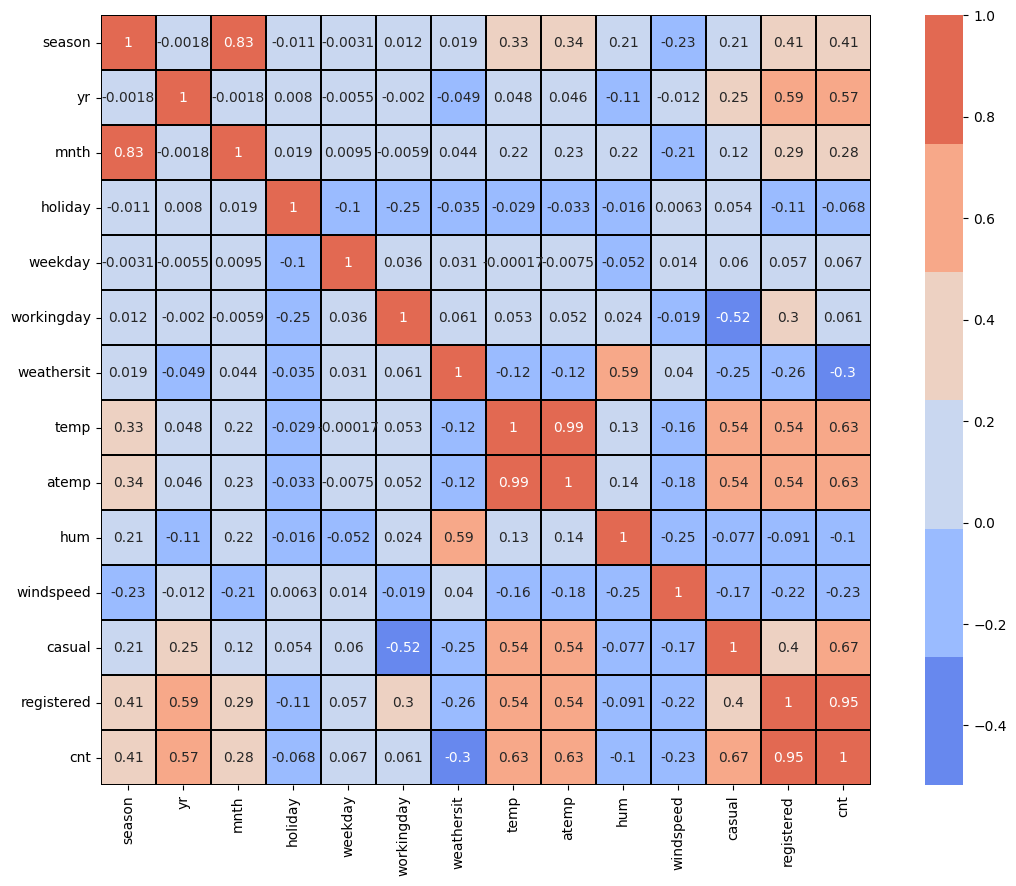

In [15]:
# Plot heatmap of correlation coefficients 
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(),
            square=True,
            linewidths=0.25,    
            linecolor=(0,0,0),
            cmap=sns.color_palette("coolwarm"),
            annot=True)
plt.show()

# | correlation |< 0.5: Low to moderate correlation.  Usually not a multicollinearity concern 
# | correlation | ≥ 0.7: high correlation.  Possible multicollinearity

In [16]:
def check_VIF(X):
    from statsmodels.stats.outliers_influence import variance_inflation_factor

    temp_df = X.assign(const=1)
    vif = pd.DataFrame()
    vif["feature"] = temp_df.columns
    vif["VIF"] = [variance_inflation_factor(temp_df.values, i) for i in range(temp_df.shape[1])]
    
    # Remove intercept row
    vif_df = vif[vif["feature"] != "const"].reset_index(drop=True)
    return vif_df
    
    #VIF > 5 → high multicollinearity (common rule of thumb)
    #VIF > 10 → serious multicollinearity
    #VIF = 1 → no multicollinearity
    #VIF is based on R² when regressing one feature on all other feature

In [17]:
check_VIF(X)

,feature,VIF
0,season,4.104348
1,yr,2.742865
2,mnth,3.360293
3,holiday,1.098107
4,weekday,1.051268
5,workingday,3.111266
6,weathersit,1.914898
7,temp,63.650194
8,atemp,64.806018
9,hum,1.948368


## Performance Evaluation

In [18]:
def compute_regression_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

def compute_mape(y_true, y_pred):
    # Mean Absolute Percentage Error
    # Note: MAPE fails if y_true contains zeros.
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def compute_smape(y_true, y_pred):
    # Symmetric Mean Absolute Percentage Error
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

def compute_rmsle(y_true, y_pred, neg_mask=0):
    # Root Mean Squared Log Error
    # RMSLE is good for right-skewed data
    # Note: log1p(x) = log(1+x), and the log parameter must be positive. 
    # Therefore, x >= -1. Otherwise, log1p(1+x) encounters an invalid value.
        
    if neg_mask == 1:
        mask = (y_true >= 0) & (y_pred >= 0)
        y_true = y_true[mask]
        y_pred = y_pred[mask]
    
    np_y_true, np_y_pred = np.array(y_true), np.array(y_pred)
    rmsle = np.sqrt(np.mean((np.log1p(np_y_true) - np.log1p(np_y_pred))**2))  # Root Mean Squared Log Error

    return rmsle

## Handling Residuals

In [19]:
# Residuals vs Fitted Plot
def create_residuals_fitted_plot(y_true, y_pred):
    residuals = y_true - y_pred
    
    plt.figure(figsize=(7, 5))
    plt.scatter(y_pred, residuals)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.xlabel("Fitted Values (Predicted)")
    plt.ylabel("Residuals")
    plt.title("Residuals vs Fitted Plot")
    plt.show()

In [20]:
# Residual qqplot
def create_residuals_qqplot(y_true, y_pred):
    residuals = y_true - y_pred
    sm.qqplot(residuals, line='45', fit=True)
    plt.title("Q-Q Plot - Statsmodels")
    plt.show()

## Check Extreme Values

In [21]:
def check_extreme_values(X_true, y_true, y_pred):
    residuals = y_true - y_pred
    
    X_computed = np.hstack([np.ones((X_true.shape[0], 1)), X_true])  # Add intercept column
    n, p = X_true.shape
    
    mse = np.sum(residuals**2) / (n - p)
    
    XtX_inv = np.linalg.inv(X_computed.T @ X_computed)  # @ = matrix multiplication operator.
    hat_matrix = X_computed @ XtX_inv @ X_computed.T 
    
    # Leverage = Outliers in X-direction = Extreme predictor values
    leverage = np.diag(hat_matrix)     
    leverage_threshold = 2 * p / n  # if leverage > 2p/n or 3p/n, leverage is considered high
    print("Leverage thresold:", leverage_threshold)
    
    # Leverage = Outliers in Y-direction = Extreme response values
    standardized_residuals = residuals / np.sqrt(mse * (1 - leverage))
    print("Standardized residuals thresold:", 2)
    
    cooks_distance = (standardized_residuals**2 / p) * (leverage / (1 - leverage))
    cooks_threshold = 4 / n
    print("Cooks thresold:", cooks_threshold)    
    cooks_df = cooks_distance[cooks_distance > cooks_threshold]
    index_to_remove = cooks_df.index.tolist()
    
    return leverage, leverage_threshold, standardized_residuals, cooks_distance, cooks_threshold, index_to_remove

In [22]:
def create_cooks_plot(X_true, cooks_distance, cooks_threshold):
    n, p = X_true.shape
    plt.figure(figsize=(10, 5))
    plt.bar(np.arange(n), cooks_distance, color='skyblue', edgecolor='k')
    plt.xlabel("Observation Index")
    plt.ylabel("Cook's Distance")
    plt.title("Cook's Distance Bar Plot")
    
    # Threshold line for influential points
    plt.axhline(y=cooks_threshold, color='red', linestyle='--', label=f"Threshold = {cooks_threshold:.4f}")
    plt.legend()
    plt.show()

In [23]:
## Example of checking extreme values for the first time
'''
leverage, leverage_threshold, standardized_residuals, cooks_distance, cooks_threshold, index_to_remove = check_extreme_values(X_train, y_train, y_train_pred)
main_index_to_remove = index_to_remove
print(main_index_to_remove)
print(len(main_index_to_remove)/df.shape[0])
create_cooks_plot(X_train, cooks_distance, cooks_threshold)
'''

'\nleverage, leverage_threshold, standardized_residuals, cooks_distance, cooks_threshold, index_to_remove = check_extreme_values(X_train, y_train, y_train_pred)\nmain_index_to_remove = index_to_remove\nprint(main_index_to_remove)\nprint(len(main_index_to_remove)/df.shape[0])\ncreate_cooks_plot(X_train, cooks_distance, cooks_threshold)\n'

In [24]:
## Example of checking extreme values after the first time
'''
leverage, leverage_threshold, standardized_residuals, cooks_distance, cooks_threshold, index_to_remove = check_extreme_values(X_train, y_train, y_train_pred)
past_main_index_to_remove = main_index_to_remove
main_index_to_remove = main_index_to_remove + index_to_remove
print(main_index_to_remove)
print(len(main_index_to_remove)/df.shape[0])
create_cooks_plot(X_train, cooks_distance, cooks_threshold)
'''

'\nleverage, leverage_threshold, standardized_residuals, cooks_distance, cooks_threshold, index_to_remove = check_extreme_values(X_train, y_train, y_train_pred)\npast_main_index_to_remove = main_index_to_remove\nmain_index_to_remove = main_index_to_remove + index_to_remove\nprint(main_index_to_remove)\nprint(len(main_index_to_remove)/df.shape[0])\ncreate_cooks_plot(X_train, cooks_distance, cooks_threshold)\n'

## Check Feature Importance

In [25]:
def get_permutation_importance(model, X, X_true, y_true):
    from sklearn.inspection import permutation_importance
    result = permutation_importance(model, X_test, y_test, n_repeats=10)
    
    perm_df = pd.DataFrame({
        "feature": X.columns,
        "importance_mean": result.importances_mean,
        "importance_std": result.importances_std
    }).sort_values("importance_mean", ascending=False)
    
    return perm_df

    # Higher value = more important feature, relatively compared to other features
    # Near-zero value = unimportant feature, relatively compared to other features
    # Negative value = noisy feature

In [26]:
def create_shap_values_plot(model, X, X_train, X_test):
    import shap
    X_train_df = pd.DataFrame(X_train, columns=X.columns.tolist())
    X_test_df = pd.DataFrame(X_test, columns=X.columns.tolist())
    explainer = shap.KernelExplainer(model.predict, X_train_df.sample(200))
    shap_values = explainer.shap_values(X_test_df.sample(100))
    shap.summary_plot(shap_values, X_test_df.sample(100))

In [27]:
def ols_model(X_true, y_true):
    import statsmodels.api as sm
    X_true_sm = sm.add_constant(X_true)

    # Fit OLS model
    ols_model = sm.OLS(y_true, X_true_sm).fit()

    # Summary table
    print(ols_model.summary())

## Experiments

In [28]:
X.columns

Index(['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual',
       'registered'],
      dtype='object')

In [29]:
# Train and test model
# Train all

selected_vars = ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual',
       'registered']
X = orig_X[selected_vars]
y = df["cnt"]

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=23)

# Construct a model
model = LinearRegression()
model.fit(X_train, y_train)

# Use model for predicted responses
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)

# Measure performances
rmse, mae, r2 = compute_regression_metrics(y_test, y_pred)
mape = compute_mape(y_test, y_pred)
print("RMSE: ", rmse)
print("MAE: ", mae)
print("MAPE: ", mape)
print("R2: ", r2)
rmsle = compute_rmsle(y_test, y_pred)
print("RMSLE: ", rmsle)

RMSE:  1.2311670983374268e-12
MAE:  9.756186788150926e-13
MAPE:  4.3467165199127894e-14
R2:  1.0
RMSLE:  9.746039845468968e-16


In [30]:
# Question: What are size of your training dataset vs. testing dataset
# Answer: training dataset -> 80% and testing dataset -> 20%

In [31]:
# Train and test model
# Remove variables that are high-correlated with y (so the model does not perfectly predict responses.)

In [32]:
# Question: What are variables that are high-correlated with y?
# Answer: casual, registered

In [33]:
selected_vars = ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed']
X = orig_X[selected_vars]
y = df["cnt"]

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=23)

# Construct a model
model = LinearRegression()
model.fit(X_train, y_train)

# Use model for predicted responses
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)

# Measure performances
rmse, mae, r2 = compute_regression_metrics(y_test, y_pred)
mape = compute_mape(y_test, y_pred)
print("RMSE: ", rmse)
print("MAE: ", mae)
print("MAPE: ", mape)
print("R2: ", r2)
rmsle = compute_rmsle(y_test, y_pred)
print("RMSLE: ", rmsle)

RMSE:  939.5939210407944
MAE:  707.7677256152434
MAPE:  25.013460231148755
R2:  0.7564049353895395
RMSLE:  nan


/tmp/ipykernel_3039/3513478318.py:30: RuntimeWarning: invalid value encountered in log1p
  rmsle = np.sqrt(np.mean((np.log1p(np_y_true) - np.log1p(np_y_pred))**2))  # Root Mean Squared Log Error


In [34]:
coeff_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_
})

print(coeff_df)

       Feature  Coefficient
0       season   556.743702
1           yr  2096.381747
2         mnth   -44.600108
3      holiday  -767.669753
4      weekday    67.786703
5   workingday    53.415852
6   weathersit  -630.284630
7         temp  2479.165928
8        atemp  2898.197876
9          hum -1098.123715
10   windspeed -2270.118772


In [35]:
# Train and test model
# Remove multi-collinearity variables (if any)

In [36]:
# Question: What are pairs or groups of multi-collinearity variables variables among predictors (X)?
# Answer: temp & atemp

In [37]:
selected_vars = ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday',
       'weathersit', 'atemp', 'hum', 'windspeed']
X = orig_X[selected_vars]
y = df["cnt"]

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=23)

# Construct a model
model = LinearRegression()
model.fit(X_train, y_train)

# Use model for predicted responses
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)

# Measure performances
rmse, mae, r2 = compute_regression_metrics(y_test, y_pred)
mape = compute_mape(y_test, y_pred)
print("RMSE: ", rmse)
print("MAE: ", mae)
print("MAPE: ", mape)
print("R2: ", r2)
rmsle = compute_rmsle(y_test, y_pred)
print("RMSLE: ", rmsle)

RMSE:  937.3527511299169
MAE:  705.7608224880398
MAPE:  24.966560581858253
R2:  0.7575656215472285
RMSLE:  nan


/tmp/ipykernel_3039/3513478318.py:30: RuntimeWarning: invalid value encountered in log1p
  rmsle = np.sqrt(np.mean((np.log1p(np_y_true) - np.log1p(np_y_pred))**2))  # Root Mean Squared Log Error


In [38]:
# Train and test model
# Continue with transform skewed variables

In [39]:
# Question: What are skewed variables among predictors (X)?
# Answer: windspeed

In [40]:
# Instruction: Place your code for transforming variables? 

In [41]:
selected_vars = ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday',
       'weathersit', 'atemp', 'hum', 'windspeed']
X = orig_X[selected_vars]
y = df["cnt"]

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=23)

skew_var = 'windspeed'
X_train = transform_log(X_train, skew_var)
# X_train = transform_boxcox(X_train, skew_var)
# X_train = transform_yeojohnson(X_train, skew_var)

# Construct a model
model = LinearRegression()
model.fit(X_train, y_train)

# Use model for predicted responses
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)

# Measure performances
rmse, mae, r2 = compute_regression_metrics(y_test, y_pred)
mape = compute_mape(y_test, y_pred)
print("RMSE: ", rmse)
print("MAE: ", mae)
print("MAPE: ", mape)
print("R2: ", r2)
rmsle = compute_rmsle(y_test, y_pred)
print("RMSLE: ", rmsle)

RMSE:  933.1199527656966
MAE:  705.3399858191254
MAPE:  24.53035734677859
R2:  0.7597501969723827
RMSLE:  nan


/tmp/ipykernel_3039/3513478318.py:30: RuntimeWarning: invalid value encountered in log1p
  rmsle = np.sqrt(np.mean((np.log1p(np_y_true) - np.log1p(np_y_pred))**2))  # Root Mean Squared Log Error


In [42]:
# Question: Does variable transformation help improve regression performance?
# Answer: Just a little

In [43]:
coeff_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_
})

print(coeff_df)

      Feature  Coefficient
0      season   556.317632
1          yr  2100.009825
2        mnth   -44.785263
3     holiday  -758.213120
4     weekday    69.918871
5  workingday    55.356854
6  weathersit  -629.404004
7       atemp  5678.740216
8         hum -1112.603253
9   windspeed -2540.036836


In [44]:
# Question: Which 3 variables do you think have the MOST effect on the response?
# Answer: atemp, windspeed, yr

In [45]:
# Question: Which 3 variables do you think have the LEAST effect on the response?
# Answer: mnth, workingday, weekday

In [46]:
# Train and test model
# Use the same set of variables as the ones with transformation.  Now, try scaling

In [47]:
# Instruction: Place the code for transformation and scaling below.

In [48]:
selected_vars = ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday',
       'weathersit', 'atemp', 'hum', 'windspeed']
X = orig_X[selected_vars]
y = df["cnt"]

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=23)

X_train, X_test = scale_standard(X_train, X_test)
# X_train, X_test = scale_minmax(X_train, X_test)
# X_train, X_test = scale_robust(X_train, X_test)

# Construct a model
model = LinearRegression()
model.fit(X_train, y_train)

# Use model for predicted responses
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)

# Measure performances
rmse, mae, r2 = compute_regression_metrics(y_test, y_pred)
mape = compute_mape(y_test, y_pred)
print("RMSE: ", rmse)
print("MAE: ", mae)
print("MAPE: ", mape)
print("R2: ", r2)
rmsle = compute_rmsle(y_test, y_pred)
print("RMSLE: ", rmsle)

RMSE:  937.3527511299174
MAE:  705.7608224880404
MAPE:  24.9665605818583
R2:  0.7575656215472283
RMSLE:  nan


/tmp/ipykernel_3039/3513478318.py:30: RuntimeWarning: invalid value encountered in log1p
  rmsle = np.sqrt(np.mean((np.log1p(np_y_true) - np.log1p(np_y_pred))**2))  # Root Mean Squared Log Error


In [49]:
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print(coeff_df)

      Feature  Coefficient
0      season   612.074853
1          yr  1049.659640
2        mnth  -152.848587
3     holiday  -127.608447
4     weekday   137.778130
5  workingday    25.506082
6  weathersit  -336.001300
7       atemp   912.159049
8         hum  -156.459950
9   windspeed  -163.940861


In [50]:
# Question: Does scaling help improve regression performance?
# Answer: No, it does the opposite. The error is increase just a little

In [51]:
# Instruction: Place code to create residuals vs fitted plot to see patterns of how residuals spread.

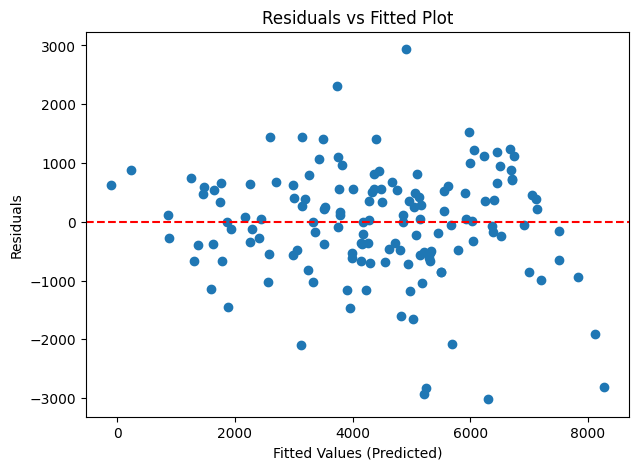

In [52]:
create_residuals_fitted_plot(y_test, y_pred)

In [53]:
# Question: What can you summarize about residuals homoscedasticity?
# Answer: The residuals of the model have an independent variables which its standard errors are unbiased and consistent

In [54]:
# Instruction: Place code to create residual qqplot to see normality of residuals.

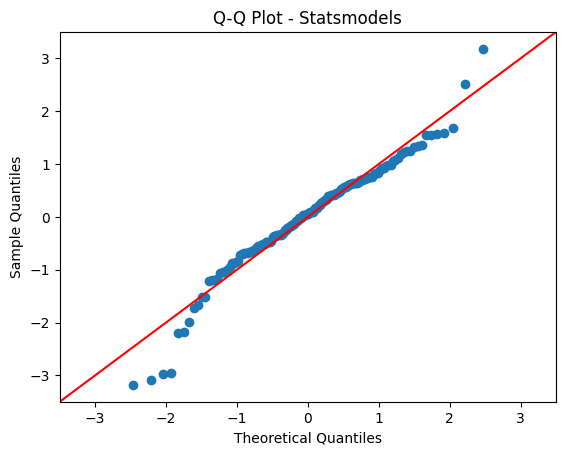

In [55]:
create_residuals_qqplot(y_test, y_pred)

In [56]:
# Question: What can you summarize about residuals normality?
# Answer: The distribution of residuals approximately normal from the Q-Q plot and its sampling distribution of estimates behaves normal

In [57]:
# Check extreme values and create a plot for cooks distance for the first time

Leverage thresold: 0.03424657534246575
Standardized residuals thresold: 2
Cooks thresold: 0.00684931506849315
0.06566347469220246


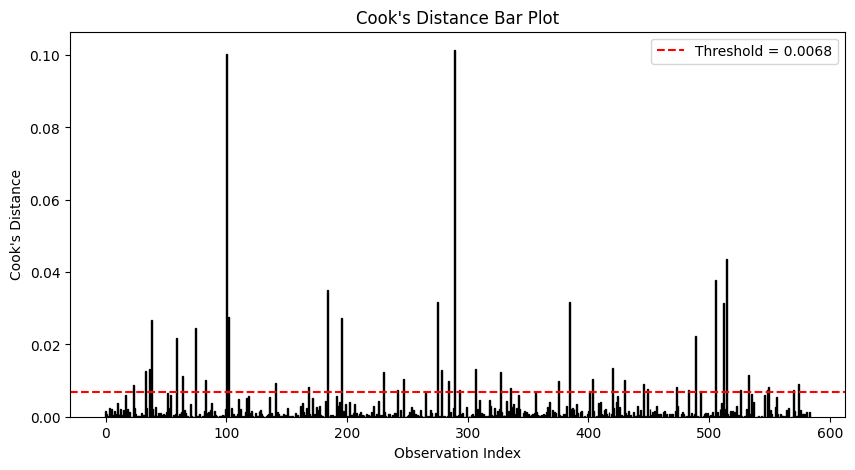

In [58]:
leverage, leverage_threshold, standardized_residuals, cooks_distance, cooks_threshold, index_to_remove = check_extreme_values(X_train, y_train, y_train_pred)
main_index_to_remove = index_to_remove
print(len(main_index_to_remove)/df.shape[0])
create_cooks_plot(X_train, cooks_distance, cooks_threshold)

In [59]:
# Train and test model
# Use the same set of variables as the ones with transformation and scaling. 
# If transformation or scaling helps with performance, include them in your codebox below

# Try to remove rows with extreme predictor values from the first time

In [60]:
# Remove extreme #1
# This given code is to remove rows with extreme values from the first time before training and testing model
df = orig_df.copy()
df = df.drop(main_index_to_remove,axis=0)
orig_X = df.drop("cnt", axis=1)
X = orig_X.copy()

selected_vars = ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday',
       'weathersit', 'atemp', 'hum', 'windspeed']
X = orig_X[selected_vars]
y = df["cnt"]

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=23)

# Construct a model
model = LinearRegression()
model.fit(X_train, y_train)

# Use model for predicted responses
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)

# Measure performances
rmse, mae, r2 = compute_regression_metrics(y_test, y_pred)
mape = compute_mape(y_test, y_pred)
print("RMSE: ", rmse)
print("MAE: ", mae)
print("MAPE: ", mape)
print("R2: ", r2)
rmsle = compute_rmsle(y_test, y_pred)
print("RMSLE: ", rmsle)

RMSE:  730.3502964379312
MAE:  552.4706011503783
MAPE:  17.968411569421434
R2:  0.8559050708495731
RMSLE:  nan


/tmp/ipykernel_3039/3513478318.py:30: RuntimeWarning: invalid value encountered in log1p
  rmsle = np.sqrt(np.mean((np.log1p(np_y_true) - np.log1p(np_y_pred))**2))  # Root Mean Squared Log Error


In [61]:
# Check extreme values and create a plot for cooks distance for the second time

Leverage thresold: 0.03663003663003663
Standardized residuals thresold: 2
Cooks thresold: 0.007326007326007326
0.10688140556368961


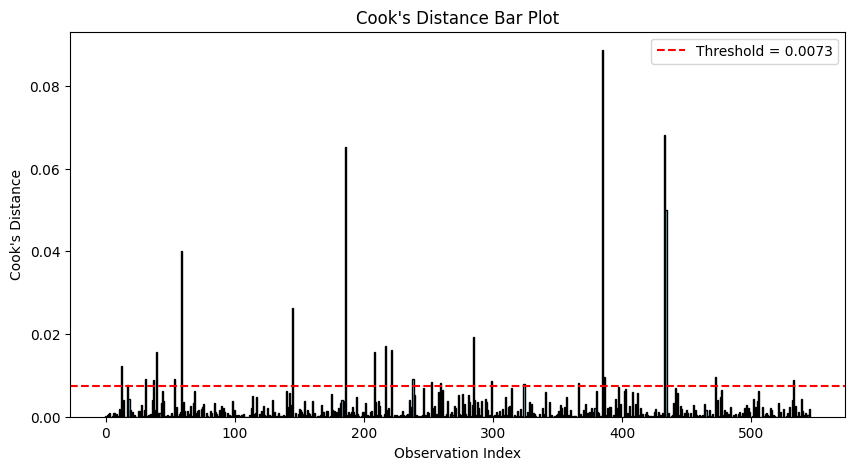

In [62]:
leverage, leverage_threshold, standardized_residuals, cooks_distance, cooks_threshold, index_to_remove = check_extreme_values(X_train, y_train, y_train_pred)
past_main_index_to_remove = main_index_to_remove
main_index_to_remove = main_index_to_remove + index_to_remove
print(len(main_index_to_remove)/df.shape[0])
create_cooks_plot(X_train, cooks_distance, cooks_threshold)

In [63]:
# Train and test model
# Use the same set of variables as the ones with transformation and scaling. 
# If transformation or scaling helps with performance, include them in your codebox below

# Try to remove rows with extreme predictor values from the second time

# Place the given code to remove rows with extreme values before training and testing model
df = orig_df.copy()
df = df.drop(main_index_to_remove,axis=0)
orig_X = df.drop("cnt", axis=1)
X = orig_X.copy()

# Note if the new performance drops lower than the previous one, you can use the following code to keep your previous verson of dataset,
df = orig_df.copy()
df = df.drop(past_main_index_to_remove,axis=0)
orig_X = df.drop("cnt", axis=1)
X = orig_X.copy()

In [64]:
# Remove extreme #2
# This given code is to remove rows with extreme values from the second time before training and testing model
df = orig_df.copy()
df = df.drop(main_index_to_remove,axis=0)
orig_X = df.drop("cnt", axis=1)
X = orig_X.copy()

selected_vars = ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday',
       'weathersit', 'atemp', 'hum', 'windspeed']
X = orig_X[selected_vars]
y = df["cnt"]

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=23)

# Construct a model
model = LinearRegression()
model.fit(X_train, y_train)

# Use model for predicted responses
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)

# Measure performances
rmse, mae, r2 = compute_regression_metrics(y_test, y_pred)
mape = compute_mape(y_test, y_pred)
print("RMSE: ", rmse)
print("MAE: ", mae)
print("MAPE: ", mape)
print("R2: ", r2)
rmsle = compute_rmsle(y_test, y_pred)
print("RMSLE: ", rmsle)

RMSE:  641.6076914859588
MAE:  495.01950119531557
MAPE:  14.617838036781095
R2:  0.8834342134740085
RMSLE:  nan


/tmp/ipykernel_3039/3513478318.py:30: RuntimeWarning: invalid value encountered in log1p
  rmsle = np.sqrt(np.mean((np.log1p(np_y_true) - np.log1p(np_y_pred))**2))  # Root Mean Squared Log Error


In [65]:
# Check extreme values and create a plot for cooks distance for the second time

Leverage thresold: 0.03802281368821293
Standardized residuals thresold: 2
Cooks thresold: 0.0076045627376425855
0.14437689969604864


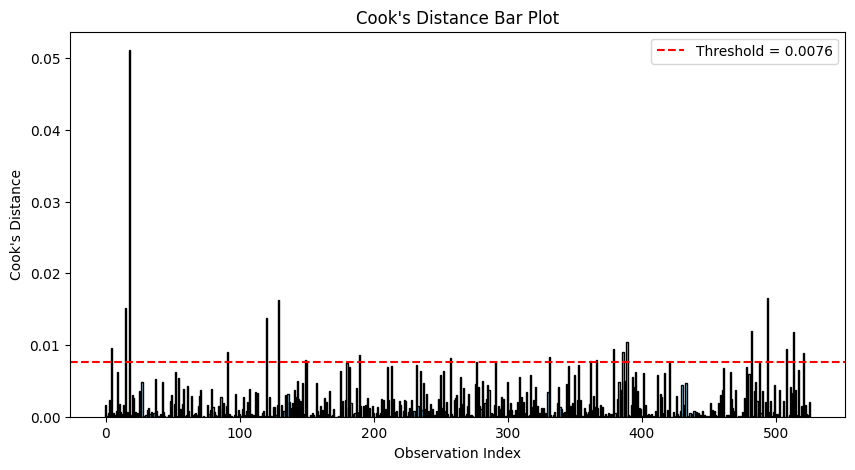

In [66]:
leverage, leverage_threshold, standardized_residuals, cooks_distance, cooks_threshold, index_to_remove = check_extreme_values(X_train, y_train, y_train_pred)
past_main_index_to_remove = main_index_to_remove
main_index_to_remove = main_index_to_remove + index_to_remove
print(len(main_index_to_remove)/df.shape[0])
create_cooks_plot(X_train, cooks_distance, cooks_threshold)

In [67]:
# You can try to remove extreme values until performance does not improve much or the removal percentage is not too much.

In [68]:
# Optional: 
# Remove extreme #3
# Check extreme values and create a plot for cooks distance for the third time
df = orig_df.copy()
df = df.drop(main_index_to_remove,axis=0)
orig_X = df.drop("cnt", axis=1)
X = orig_X.copy()

selected_vars = ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday',
       'weathersit', 'atemp', 'hum', 'windspeed']
X = orig_X[selected_vars]
y = df["cnt"]

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=23)

# Construct a model
model = LinearRegression()
model.fit(X_train, y_train)

# Use model for predicted responses
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)

# Measure performances
rmse, mae, r2 = compute_regression_metrics(y_test, y_pred)
mape = compute_mape(y_test, y_pred)
print("RMSE: ", rmse)
print("MAE: ", mae)
print("MAPE: ", mape)
print("R2: ", r2)
rmsle = compute_rmsle(y_test, y_pred)
print("RMSLE: ", rmsle)

RMSE:  585.4106265403251
MAE:  483.4805893197921
MAPE:  13.332926242338477
R2:  0.8984621873275138
RMSLE:  nan


/tmp/ipykernel_3039/3513478318.py:30: RuntimeWarning: invalid value encountered in log1p
  rmsle = np.sqrt(np.mean((np.log1p(np_y_true) - np.log1p(np_y_pred))**2))  # Root Mean Squared Log Error


Leverage thresold: 0.03937007874015748
Standardized residuals thresold: 2
Cooks thresold: 0.007874015748031496
0.18238993710691823


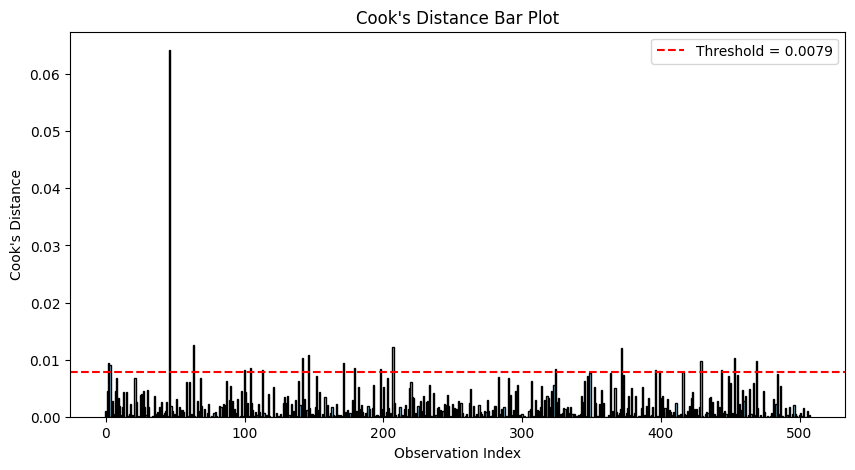

In [69]:
leverage, leverage_threshold, standardized_residuals, cooks_distance, cooks_threshold, index_to_remove = check_extreme_values(X_train, y_train, y_train_pred)
past_main_index_to_remove = main_index_to_remove
main_index_to_remove = main_index_to_remove + index_to_remove
print(len(main_index_to_remove)/df.shape[0])
create_cooks_plot(X_train, cooks_distance, cooks_threshold)

In [70]:
# Question: When you are done with extreme value removal, what is size of your training dataset now?
# Answer: (636, 16)
df.shape

(636, 16)

In [71]:
# Place code to compute permutation importance

In [72]:
get_permutation_importance(model, X, X_test, y_test)

,feature,importance_mean,importance_std
1,yr,0.701948,0.059144
7,atemp,0.535402,0.046546
0,season,0.137117,0.018998
6,weathersit,0.045377,0.010180
8,hum,0.015467,0.006301
4,weekday,0.011748,0.003887
9,windspeed,0.010026,0.004789
3,holiday,0.003530,0.002165
5,workingday,0.000371,0.001042
2,mnth,-0.000186,0.000239


In [73]:
# Place code to create plot for shap values 

/home/hamtako/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
100%|█████████████████████████████████████████████████████████████████████████████████| 100/100 [00:03<00:00, 28.20it/s]


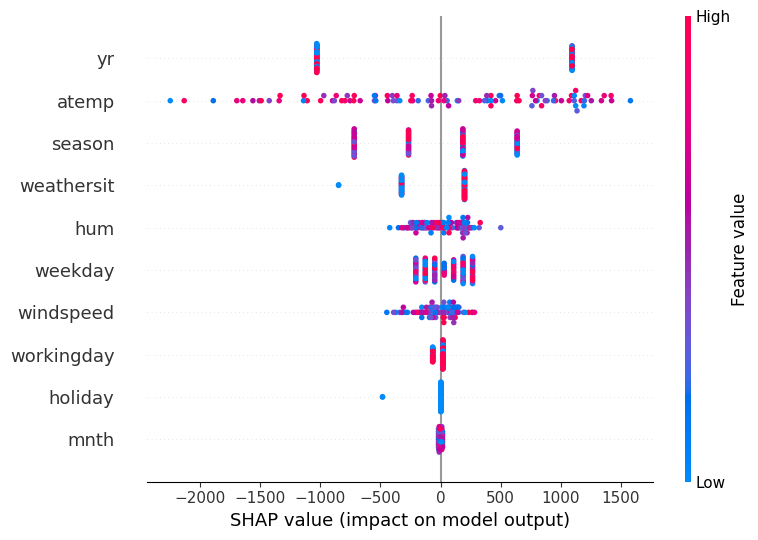

In [74]:
create_shap_values_plot(model, X, X_train, X_test)

In [75]:
# This is to report p-values and confidence of each coefficients
ols_model(X_train, y_train)

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.895
Model:                            OLS   Adj. R-squared:                  0.892
Method:                 Least Squares   F-statistic:                     421.6
Date:                Mon, 15 Dec 2025   Prob (F-statistic):          1.79e-235
Time:                        12:21:50   Log-Likelihood:                -3970.9
No. Observations:                 508   AIC:                             7964.
Df Residuals:                     497   BIC:                             8010.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1207.8010    197.935      6.102      0.0

p-value tells us about alpha 0.1 then p-value of mnth and workingday which not rejected the null hypothesis therefore mnth and workingday do not influence.

In [76]:
# Question: From permutation importance, shap values, p-values, which one do you think they are "important" varaibles? 
#           Note that the number of important variables should be fewer than original number of varaibles.
# Answer: yr, atemp and season

In [77]:
X.columns

Index(['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday',
       'weathersit', 'atemp', 'hum', 'windspeed'],
      dtype='object')

In [78]:
# Train and test model
# Use important variables from your answer above to construct a model 

In [79]:
# Train and test model

selected_vars = ['yr', 'atemp', 'season']
X = orig_X[selected_vars]
y = df["cnt"]

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=23)

# Construct a model
model = LinearRegression()
model.fit(X_train, y_train)

# Use model for predicted responses
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)

# Measure performances
rmse, mae, r2 = compute_regression_metrics(y_test, y_pred)
mape = compute_mape(y_test, y_pred)
print("RMSE: ", rmse)
print("MAE: ", mae)
print("MAPE: ", mape)
print("R2: ", r2)
rmsle = compute_rmsle(y_test, y_pred)
print("RMSLE: ", rmsle)

RMSE:  712.4347748537311
MAE:  561.8853817078503
MAPE:  15.163784732071129
R2:  0.8496176663606319
RMSLE:  0.20365971986751213


In [80]:
# Train and test model
# From your important variables above, reduce one of them.  Use the remaining to construct a model.

In [81]:
# selected_vars = ['yr', 'atemp']
# X = orig_X[selected_vars]
# y = df["cnt"]

# # Train/Test Split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=23)

# # Construct a model
# model = LinearRegression()
# model.fit(X_train, y_train)

# # Use model for predicted responses
# y_train_pred = model.predict(X_train)
# y_pred = model.predict(X_test)

# # Measure performances
# rmse, mae, r2 = compute_regression_metrics(y_test, y_pred)
# mape = compute_mape(y_test, y_pred)
# print("RMSE: ", rmse)
# print("MAE: ", mae)
# print("MAPE: ", mape)
# print("R2: ", r2)
# rmsle = compute_rmsle(y_test, y_pred)
# print("RMSLE: ", rmsle)

In [82]:
# Place code to create residuals vs fitted plot and residual qqplot for the latest regression model 

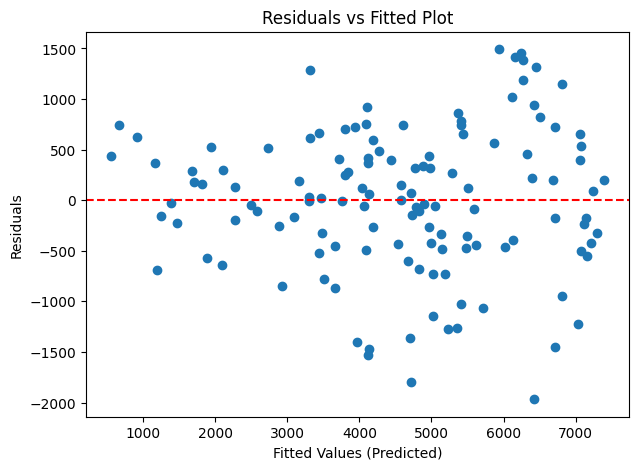

In [83]:
create_residuals_fitted_plot(y_test, y_pred)

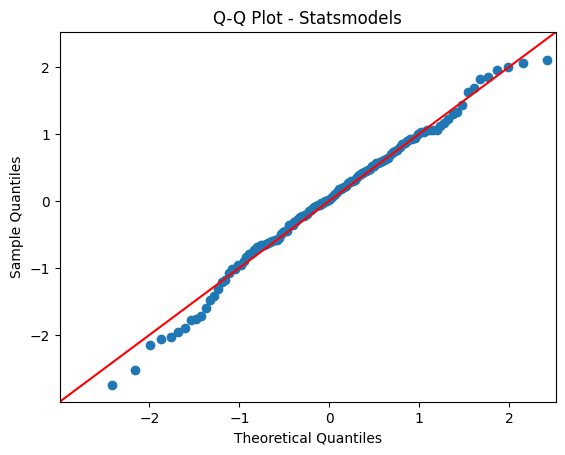

In [84]:
create_residuals_qqplot(y_test, y_pred)

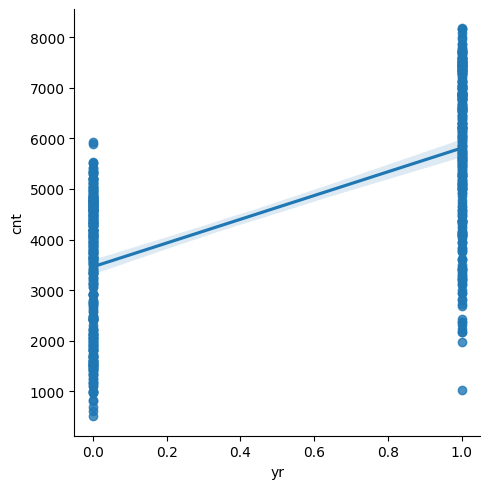

In [85]:
# You can use the following code to plot one important variable vs. response and see their relationship.
selected_var = 'yr'
predict_var = 'cnt'
sns.lmplot(x=selected_var, y=predict_var, data=df)

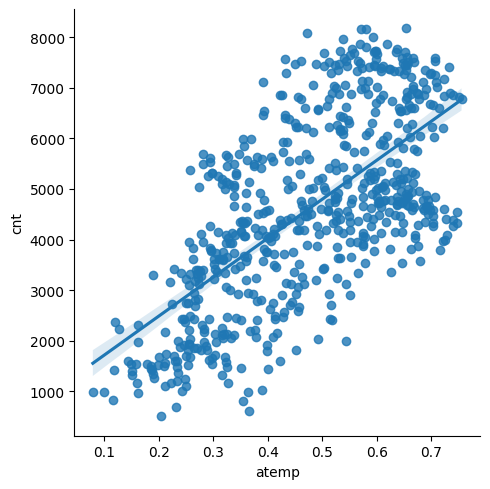

In [86]:
selected_var = 'atemp'
predict_var = 'cnt'
sns.lmplot(x=selected_var, y=predict_var, data=df)

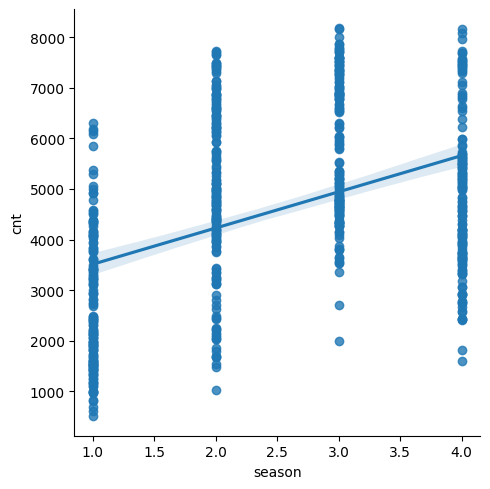

In [87]:
selected_var = 'season'
predict_var = 'cnt'
sns.lmplot(x=selected_var, y=predict_var, data=df)

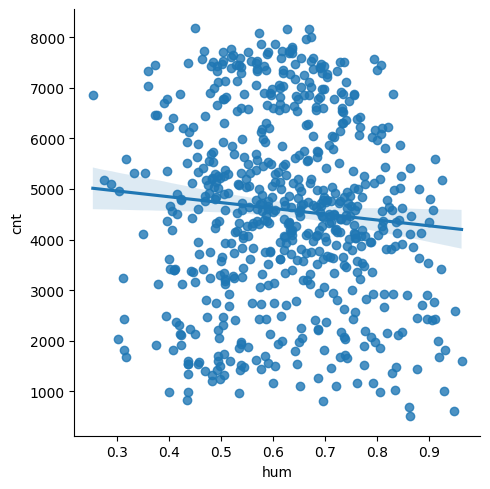

In [88]:
selected_var = 'hum'
predict_var = 'cnt'
sns.lmplot(x=selected_var, y=predict_var, data=df)